# Movie Recommendation System

## Objective

Build a content-based movie recommendation system using:

- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Cosine Similarity

The system will recommend similar movies based on movie descriptions.

In [38]:
# Cell 1 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [39]:
# Cell 2 - Load Data
movies = pd.read_csv("../data/tmdb_5000_movies.csv")
credits = pd.read_csv("../data/tmdb_5000_credits.csv")

print("Movies Shape:", movies.shape)
print("Credits Shape:", credits.shape)

Movies Shape: (4803, 20)
Credits Shape: (4803, 4)


In [40]:
# Cell 3 - Preview Data

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [41]:
# Cell 4 - Preview Data

movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [42]:
# Cell 5 - Dataset Overview

movies = movies.merge(
    credits,
    on="title"
)

movies.shape

(4809, 23)

In [43]:
# Cell 6 - Merge Datasets

movies = movies[
    [
        "movie_id",
        "title",
        "overview",
        "genres",
        "keywords",
        "cast",
        "crew",
        "vote_average"
    ]
]

movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,vote_average
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1


In [44]:
# Cell 7 - Missing Values

movies.isnull().sum()

movie_id        0
title           0
overview        3
genres          0
keywords        0
cast            0
crew            0
vote_average    0
dtype: int64

In [45]:
#Cell 8 - Remove Missing Records

movies.dropna(inplace=True)

movies.shape

(4806, 8)

In [46]:
# Cell 9 - EDA: Most Common Genres

movies["genres"].head()

0    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1    [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3    [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4    [{"id": 28, "name": "Action"}, {"id": 12, "nam...
Name: genres, dtype: object

In [47]:
# Cell 10 - Create Feature Column

movies["tags"] = movies["overview"]

movies[["title", "tags"]].head()

,title,tags
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca..."


In [48]:
# Cell 11 - Basic Cleaning

movies["tags"] = movies["tags"].str.lower()

movies["tags"].head()

0    in the 22nd century, a paraplegic marine is di...
1    captain barbossa, long believed to be dead, ha...
2    a cryptic message from bond’s past sends him o...
3    following the death of district attorney harve...
4    john carter is a war-weary, former military ca...
Name: tags, dtype: object

In [49]:
# Cell 12 - TF-IDF Vectorization

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

vectors = tfidf.fit_transform(
    movies["tags"]
)

vectors.shape

(4806, 5000)

In [50]:
# Cell 13 - Similarity Matrix

similarity = cosine_similarity(
    vectors
)

similarity.shape

(4806, 4806)

In [51]:
# Cell 14 - Recommendation Function

def recommend(movie_name):

    movie_index = movies[
        movies["title"] == movie_name
    ].index[0]

    distances = similarity[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print(f"\nRecommendations for '{movie_name}':\n")

    for movie in movie_list:
        print(
            movies.iloc[movie[0]].title
        )

In [52]:
# Cell 15 - Test Recommendation System
recommend("Avatar")
##recommend("Interstellar")
##recommend("The Dark Knight")


Recommendations for 'Avatar':

Apollo 18
The American
Beowulf
Tears of the Sun
The Adventures of Pluto Nash


In [55]:
# Cell 16 - Most Popular Movies
top_movies = movies[
    ["title", "vote_average"]
].sort_values(
    by="vote_average",
    ascending=False
)

top_movies.head(10)

,title,vote_average
4050,"Dancer, Texas Pop. 81",10.0
4252,Me You and Five Bucks,10.0
3522,Stiff Upper Lips,10.0
4668,Little Big Top,10.0
3997,Sardaarji,9.5
2388,One Man's Hero,9.3
1883,The Shawshank Redemption,8.5
2973,There Goes My Baby,8.5
2798,The Prisoner of Zenda,8.4
3340,The Godfather,8.4


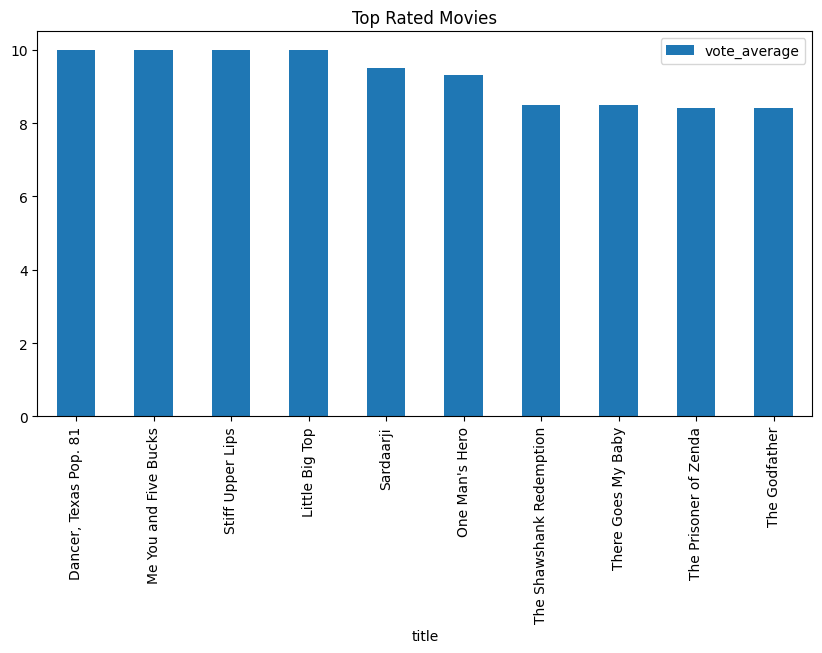

In [56]:
# Cell 17 - Visualization

top_movies.head(10).plot(
    x="title",
    y="vote_average",
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top Rated Movies"
)

plt.show()

In [58]:
# Cell 18 - Save Processed Dataset

movies.to_csv(
    "../results/processed_movies.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [59]:
# Cell 19 - Save Similarity Matrix
import pickle

pickle.dump(
    movies,
    open("../models/movies.pkl", "wb")
)

pickle.dump(
    similarity,
    open("../models/similarity.pkl", "wb")
)

print("Models Saved")

Models Saved
